# Exp 2 — Feature Engineering

Systematically engineer and evaluate features for the taxi supply shortage predictor.
All features engineered with strict no-leakage discipline (temporal split, shift-based lags).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# =========================================================
# 1. LOAD DATA
# =========================================================

In [ ]:
# ── Data Loading ──────────────────────────────────────────────────────────────
#  Priority 1: real LTA data  →  data/processed/training.parquet
#              Build with: python scripts/build_training_data.py
#  Priority 2: 90-day synthetic fallback (reproducible, seed=42)
# ──────────────────────────────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path
from backend.preprocessing.pipeline import _SG_HOLIDAY_DATES, _SG_SCHOOL_HOLIDAY_RANGES

TRAINING_PARQUET = Path("../data/processed/training.parquet")

if TRAINING_PARQUET.exists():
    df = pd.read_parquet(TRAINING_PARQUET)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = True
    shortage_rate = df["supply_shortage"].dropna().mean()
    print(f"Real LTA data: {len(df):,} rows | shortage rate: {shortage_rate:.2%} | "
          f"{df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
else:
    from backend.ingestion.loader import generate_synthetic_data
    df = generate_synthetic_data(start="2024-01-01", days=90, seed=42)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = False
    print("Synthetic data (run `python scripts/build_training_data.py` to use real LTA data)")

# ── Target: supply drops >40% in next hour? ───────────────────────────────────
if "supply_shortage" not in df.columns:
    df["taxi_count_next"] = df.groupby("zone_id")["taxi_count"].shift(-1)
    df["supply_shortage"] = (df["taxi_count_next"] < df["taxi_count"] * 0.6).astype("Int64")
    df = df.dropna(subset=["supply_shortage"]).copy()
    df["supply_shortage"] = df["supply_shortage"].astype(int)

# ── Base time features (needed for FE steps below, skip if already present) ──
import numpy as np
if "hour_of_day" not in df.columns:
    df["hour_of_day"]  = df["timestamp"].dt.hour
    df["day_of_week"]  = df["timestamp"].dt.dayofweek
    df["month"]        = df["timestamp"].dt.month
    df["is_weekend"]   = df["day_of_week"] >= 5
    df["is_peak_hour"] = df["hour_of_day"].isin(set(range(7,10)) | set(range(17,21)))

# ── Calendar flags ─────────────────────────────────────────────────────────────
import pandas as _pd
ts = df["timestamp"]
tomorrow_strs = (ts + _pd.Timedelta(days=1)).dt.strftime("%Y-%m-%d")
df["is_eve_holiday"] = tomorrow_strs.isin(_SG_HOLIDAY_DATES).astype(bool)

if "is_school_holiday" not in df.columns:
    is_school_hol = _pd.Series(False, index=df.index)
    for start_str, end_str in _SG_SCHOOL_HOLIDAY_RANGES:
        start_ts = _pd.Timestamp(start_str, tz="Asia/Singapore")
        end_ts   = _pd.Timestamp(end_str,   tz="Asia/Singapore") + _pd.Timedelta(days=1)
        is_school_hol |= (ts >= start_ts) & (ts < end_ts)
    df["is_school_holiday"] = is_school_hol.astype(bool)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Shortage rate: {df['supply_shortage'].mean():.2%}")

# =========================================================
# 2. QUICK SUMMARY — Exp 1 Baseline
# =========================================================

In [3]:
# Reference numbers from Exp 1 — Decision Tree (9 features, no lag engineering)
EXP1 = {"features": 9, "auc": 0.8274, "f1": 0.4128, "precision": 0.4880, "recall": 0.3576}
print("Exp 1 baseline (Decision Tree, 9 features)")
print(f"  AUC-ROC   : {EXP1['auc']:.4f}")
print(f"  F1        : {EXP1['f1']:.4f}")
print(f"  Precision : {EXP1['precision']:.4f}")
print(f"  Recall    : {EXP1['recall']:.4f}")
print()
print("Goal: beat AUC > 0.83 and F1 > 0.42 with better features.")

Exp 1 baseline (Decision Tree, 9 features)
  AUC-ROC   : 0.8274
  F1        : 0.4128
  Precision : 0.4880
  Recall    : 0.3576

Goal: beat AUC > 0.83 and F1 > 0.42 with better features.


# =========================================================
# 3. FEATURE ENGINEERING
# =========================================================

## 3.1 Extended Lag Features
All lags use `shift(N)` — N ≥ 1 ensures no look-ahead into future values.

In [4]:
grp = df.groupby("zone_id")["taxi_count"]

# Lags: 1h already in base, adding 2h, 3h, 48h
df["taxi_lag_1h"]   = grp.shift(1)
df["taxi_lag_2h"]   = grp.shift(2)
df["taxi_lag_3h"]   = grp.shift(3)
df["taxi_lag_24h"]  = grp.shift(24)
df["taxi_lag_48h"]  = grp.shift(48)
df["taxi_lag_168h"] = grp.shift(168)   # same hour last week

# Fill lags with zone mean where unavailable (start of series)
for col in ["taxi_lag_1h","taxi_lag_2h","taxi_lag_3h","taxi_lag_24h","taxi_lag_48h","taxi_lag_168h"]:
    zone_means = df.groupby("zone_id")[col].transform("mean")
    df[col] = df[col].fillna(zone_means)

print("Lag features created:")
lag_cols = [c for c in df.columns if "lag" in c]
print(df[lag_cols].describe().round(2))

Lag features created:
       taxi_lag_1h  taxi_lag_2h  taxi_lag_3h  taxi_lag_24h  taxi_lag_48h  \
count  118800.0000  118800.0000  118800.0000   118800.0000   118800.0000   
mean       28.8300      28.8300      28.8300       28.7900       28.8000   
std        18.6300      18.6200      18.6200       18.5500       18.5500   
min         1.0000       1.0000       1.0000        1.0000        1.0000   
25%        17.0000      17.0000      17.0000       17.0000       17.0000   
50%        26.0000      26.0000      26.0000       26.0000       26.0000   
75%        36.0000      36.0000      36.0000       36.0000       36.0000   
max       106.0000     106.0000     106.0000      106.0000      106.0000   

       taxi_lag_168h  
count    118800.0000  
mean         28.7200  
std          18.3000  
min           1.0000  
25%          17.0000  
50%          25.0000  
75%          36.0000  
max         106.0000  


## 3.2 Rolling Window Statistics
`shift(1)` inside each transform prevents the current value from leaking into its own window.

In [5]:
grp = df.groupby("zone_id")["taxi_count"]

# Rolling means — windows: 3h, 6h, 12h, 24h
for w in [3, 6, 12, 24]:
    col = f"taxi_rolling_{w}h_mean"
    rolled = grp.transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
    zone_means = grp.transform("mean")
    df[col] = rolled.fillna(zone_means)

# Rolling std — captures volatility (high std → unstable supply)
for w in [3, 6]:
    col = f"taxi_rolling_{w}h_std"
    df[col] = grp.transform(
        lambda s: s.shift(1).rolling(w, min_periods=2).std()
    ).fillna(0).clip(0)

# Rolling max and min over 3h — captures supply ceiling and floor
df["taxi_rolling_3h_max"] = grp.transform(lambda s: s.shift(1).rolling(3, min_periods=1).max())
df["taxi_rolling_3h_min"] = grp.transform(lambda s: s.shift(1).rolling(3, min_periods=1).min())

# Range = max - min: wide range = high volatility
df["taxi_rolling_3h_range"] = df["taxi_rolling_3h_max"] - df["taxi_rolling_3h_min"]

roll_cols = [c for c in df.columns if "rolling" in c]
print(f"Rolling features created: {roll_cols}")

Rolling features created: ['taxi_rolling_3h_mean', 'taxi_rolling_6h_mean', 'taxi_rolling_12h_mean', 'taxi_rolling_24h_mean', 'taxi_rolling_3h_std', 'taxi_rolling_6h_std', 'taxi_rolling_3h_max', 'taxi_rolling_3h_min', 'taxi_rolling_3h_range']


## 3.3 Depletion Rates & Supply Trend
Depletion rate = how fast supply is being absorbed relative to recent baseline.

In [6]:
# Depletion rate: (lag - current) / (lag + 1)
# Positive = supply dropped (taxis being hired)
# Negative = supply recovered
df["depletion_rate_1h"] = ((df["taxi_lag_1h"]  - df["taxi_count"]) / (df["taxi_lag_1h"]  + 1)).clip(-2, 2)
df["depletion_rate_3h"] = ((df["taxi_rolling_3h_mean"] - df["taxi_count"]) / (df["taxi_rolling_3h_mean"] + 1)).clip(-2, 2)
df["depletion_rate_6h"] = ((df["taxi_rolling_6h_mean"] - df["taxi_count"]) / (df["taxi_rolling_6h_mean"] + 1)).clip(-2, 2)

# Supply vs yesterday (same hour, same zone)
df["supply_vs_yesterday"] = (df["taxi_count"] / (df["taxi_lag_24h"] + 1)).clip(0, 5)

# Supply trend: short-term mean vs medium-term mean
# Positive = recent supply higher than 6h average (recovering)
# Negative = recent supply below 6h average (deteriorating)
df["supply_trend_3v6"]  = df["taxi_rolling_3h_mean"] - df["taxi_rolling_6h_mean"]
df["supply_trend_6v12"] = df["taxi_rolling_6h_mean"] - df["taxi_rolling_12h_mean"]

depletion_cols = [c for c in df.columns if "depletion" in c or "trend" in c or "yesterday" in c]
print(f"Depletion/trend features: {depletion_cols}")
print(df[depletion_cols].describe().round(3))

Depletion/trend features: ['depletion_rate_1h', 'depletion_rate_3h', 'depletion_rate_6h', 'supply_vs_yesterday', 'supply_trend_3v6', 'supply_trend_6v12']
       depletion_rate_1h  depletion_rate_3h  depletion_rate_6h  \
count        118800.0000        118800.0000        118800.0000   
mean             -0.0930            -0.0440            -0.0290   
std               0.4830             0.4230             0.4010   
min              -2.0000            -2.0000            -2.0000   
25%              -0.3210            -0.2500            -0.2630   
50%               0.0000             0.0200             0.0310   
75%               0.2500             0.2500             0.2690   
max               0.8320             0.8210             0.8140   

       supply_vs_yesterday  supply_trend_3v6  supply_trend_6v12  
count          118800.0000       118800.0000        118800.0000  
mean                1.0140            0.0090             0.0190  
std                 0.4080            5.4160         

## 3.4 Cyclical Encoding & Time Context
Cyclical encoding prevents the model treating hour 23 and hour 0 as far apart.

In [7]:
# Hour and day cyclical (already in pipeline, reproducing here for completeness)
df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)
df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Month cyclical — captures monsoon seasonality (Nov-Jan = more rain = more shortages)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Hours to next peak — how close are we to the next demand surge?
# Peaks: 7am (morning rush) and 5pm (evening rush)
def hours_to_next_peak(h):
    return min((p - h) % 24 for p in [7, 17])

df["hours_to_peak"] = df["hour_of_day"].map(hours_to_next_peak)

print("Cyclical features + time context:")
time_cols = ["hour_sin","hour_cos","dow_sin","dow_cos","month_sin","month_cos","hours_to_peak"]
print(df[time_cols].describe().round(3))

Cyclical features + time context:
         hour_sin    hour_cos     dow_sin     dow_cos   month_sin   month_cos  \
count 118800.0000 118800.0000 118800.0000 118800.0000 118800.0000 118800.0000   
mean      -0.0000     -0.0000      0.0090     -0.0070      0.7850      0.4590   
std        0.7070      0.7070      0.7060      0.7080      0.2130      0.3580   
min       -1.0000     -1.0000     -0.9750     -0.9010      0.5000      0.0000   
25%       -0.7070     -0.7070     -0.7820     -0.9010      0.5000      0.0000   
50%        0.0000     -0.0000      0.0000     -0.2230      0.8660      0.5000   
75%        0.7070      0.7070      0.7820      0.6230      1.0000      0.8660   
max        1.0000      1.0000      0.9750      1.0000      1.0000      0.8660   

       hours_to_peak  
count    118800.0000  
mean          5.6670  
std           3.7270  
min           0.0000  
25%           2.7500  
50%           5.5000  
75%           8.2500  
max          13.0000  


## 3.5 Weather Interaction Features
Rain during peak hours compounds shortage risk multiplicatively.

In [8]:
# Rain × peak hour: worst combination for shortage
df["rain_x_peak"] = df["is_raining"].astype(int) * df["is_peak_hour"].astype(int)

# Rain intensity × depletion: heavy rain during already-depleting period
df["rain_x_depletion"] = df["rainfall_mm"] * df["depletion_rate_1h"].clip(0, None)

# Square-root of rainfall — dampens extreme outliers
df["rainfall_sqrt"] = np.sqrt(df["rainfall_mm"])

# Rain intensity bucket (0=none, 1=light<2mm, 2=moderate 2-10mm, 3=heavy>10mm)
df["rain_intensity"] = pd.cut(
    df["rainfall_mm"],
    bins=[-0.1, 0.0, 2.0, 10.0, float("inf")],
    labels=[0, 1, 2, 3]
).astype(int)

weather_new = ["rain_x_peak", "rain_x_depletion", "rainfall_sqrt", "rain_intensity"]
print("Weather interaction features:")
print(df[weather_new].describe().round(3))

print(f"\nShortage rate — rain × peak: {df[df['rain_x_peak']==1]['supply_shortage'].mean():.2%}")
print(f"Shortage rate — dry + off-peak: {df[(df['is_raining']==False)&(df['is_peak_hour']==False)]['supply_shortage'].mean():.2%}")

Weather interaction features:
       rain_x_peak  rain_x_depletion  rainfall_sqrt  rain_intensity
count  118800.0000       118800.0000    118800.0000     118800.0000
mean        0.1250            0.4820         0.8300          0.7550
std         0.3310            1.3070         1.1880          0.9870
min         0.0000            0.0000         0.0000          0.0000
25%         0.0000            0.0000         0.0000          0.0000
50%         0.0000            0.0000         0.0000          0.0000
75%         0.0000            0.1970         1.6090          2.0000
max         1.0000           31.3550         7.7370          3.0000

Shortage rate — rain × peak: 1.01%
Shortage rate — dry + off-peak: 21.92%


## 3.6 Zone Type Encoding
Ordinal encoding of zone type for tree-based models.

In [9]:
ZONE_TYPE_ENC = {"CBD": 0, "transport_hub": 1, "residential": 2, "mixed": 3, "industrial": 4}
df["zone_type_encoded"] = df["zone_type"].map(ZONE_TYPE_ENC).fillna(3).astype(int)

print("Zone type distribution + shortage rate:")
print(
    df.groupby("zone_type")
    .agg(count=("supply_shortage","count"), shortage_rate=("supply_shortage","mean"))
    .round(3)
)

Zone type distribution + shortage rate:
               count  shortage_rate
zone_type                          
CBD            23760         0.1430
industrial     15120         0.1340
mixed          62640         0.1160
transport_hub  17280         0.1380


## 3.7 Feature Summary
Full list of engineered features before selection.

In [10]:
ENGINEERED_FEATURES = [
    # Supply state
    "taxi_count",
    "taxi_lag_1h", "taxi_lag_2h", "taxi_lag_3h",
    "taxi_lag_24h", "taxi_lag_48h", "taxi_lag_168h",
    # Rolling stats
    "taxi_rolling_3h_mean", "taxi_rolling_6h_mean",
    "taxi_rolling_12h_mean", "taxi_rolling_24h_mean",
    "taxi_rolling_3h_std",  "taxi_rolling_6h_std",
    "taxi_rolling_3h_max",  "taxi_rolling_3h_min", "taxi_rolling_3h_range",
    # Depletion & trend
    "depletion_rate_1h", "depletion_rate_3h", "depletion_rate_6h",
    "supply_vs_yesterday", "supply_trend_3v6", "supply_trend_6v12",
    # Time
    "hour_of_day", "day_of_week", "month",
    "is_weekend", "is_peak_hour",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "month_sin", "month_cos", "hours_to_peak",
    # Weather
    "rainfall_mm", "rainfall_sqrt", "is_raining", "rain_intensity",
    "temperature_c", "rain_x_peak", "rain_x_depletion",
    # Calendar
    "is_holiday", "is_eve_holiday", "is_school_holiday",
    # External (LTA)
    "carpark_available_lots", "congestion_ratio",
    # Zone identity
    "zone_type_encoded",
]
# zone_name and region will be one-hot encoded separately in step 7

print(f"Total engineered features: {len(ENGINEERED_FEATURES)}")
print(f"(Exp 1 had: {EXP1['features']} features)")

# Confirm all columns exist
missing = [c for c in ENGINEERED_FEATURES if c not in df.columns]
print(f"Missing columns: {missing if missing else 'None ✓'}")

Total engineered features: 47
(Exp 1 had: 9 features)
Missing columns: None ✓


# =========================================================
# 4. LEAKAGE AUDIT
# =========================================================

In [11]:
print("=== LEAKAGE AUDIT ===")
print()

# Check 1: target-derived column not in features
assert "taxi_count_next" not in ENGINEERED_FEATURES, "FAIL: taxi_count_next in features!"
print("✓ taxi_count_next not in feature set")

# Check 2: all lag features use at least shift(1)
# Discrete integer taxi counts can coincidentally repeat across consecutive hours,
# so a small overlap rate is expected even with correct shift(1). Flag only if >15%.
lag_equals_current = (df["taxi_lag_1h"] == df["taxi_count"]).mean()
assert lag_equals_current < 0.15, f"FAIL: taxi_lag_1h too similar to taxi_count ({lag_equals_current:.1%}) — shift likely not applied"
print(f"✓ taxi_lag_1h shift confirmed ({lag_equals_current:.1%} same-value overlap — normal for discrete integer counts)")

# Check 3: rolling features are shifted (rolling_3h should not equal taxi_count)
roll_equals_current = (df["taxi_rolling_3h_mean"].round(0) == df["taxi_count"]).mean()
assert roll_equals_current < 0.10, f"FAIL: rolling_3h_mean too similar to taxi_count"
print(f"✓ taxi_rolling_3h_mean ≠ taxi_count (only {roll_equals_current:.1%} exact matches)")

# Check 4: depletion rate uses lag, not current-vs-future
# depletion_rate_1h = (lag1 - current) / (lag1 + 1) — all inputs are t-1 or t
assert "taxi_count_next" not in str(df["depletion_rate_1h"].name), "FAIL"
print("✓ depletion_rate_1h uses lag_1h and taxi_count — no future data")

# Check 5: train/test split will be temporal (no shuffle)
print("✓ Train/test split will be temporal (shuffle=False) — see section 6")

# Check 6: zone normalization will be fit on train only
print("✓ Zone normalization baseline computed on train set only — see section 7")

print()
print("All leakage checks passed.")

=== LEAKAGE AUDIT ===

✓ taxi_count_next not in feature set
✓ taxi_lag_1h shift confirmed (5.9% same-value overlap — normal for discrete integer counts)
✓ taxi_rolling_3h_mean ≠ taxi_count (only 5.7% exact matches)
✓ depletion_rate_1h uses lag_1h and taxi_count — no future data
✓ Train/test split will be temporal (shuffle=False) — see section 6
✓ Zone normalization baseline computed on train set only — see section 7

All leakage checks passed.


# =========================================================
# 5. FEATURE SELECTION
# =========================================================

In [12]:
# Quick selection pass using mutual information (no train/test split needed here
# as MI is computed per-feature independently — no model fitting involved)
# We use a sample to keep it fast.

X_sel = df[ENGINEERED_FEATURES].copy()
# Cast booleans
for col in X_sel.select_dtypes(include="bool").columns:
    X_sel[col] = X_sel[col].astype(int)
X_sel = X_sel.fillna(0)

y_sel = df["supply_shortage"]

mi_scores = mutual_info_classif(X_sel, y_sel, random_state=42, n_jobs=-1)
mi_df = pd.Series(mi_scores, index=ENGINEERED_FEATURES).sort_values(ascending=False)

print("Mutual Information scores (higher = more informative):")
print(mi_df.to_string())

Mutual Information scores (higher = more informative):
hour_of_day              0.0548
is_raining               0.0460
hour_cos                 0.0435
depletion_rate_6h        0.0427
depletion_rate_3h        0.0394
rain_intensity           0.0375
hours_to_peak            0.0366
taxi_count               0.0364
depletion_rate_1h        0.0361
supply_vs_yesterday      0.0345
rainfall_sqrt            0.0316
rainfall_mm              0.0316
hour_sin                 0.0310
rain_x_depletion         0.0254
congestion_ratio         0.0200
rain_x_peak              0.0162
zone_type_encoded        0.0114
is_peak_hour             0.0100
month_sin                0.0097
carpark_available_lots   0.0094
month_cos                0.0070
taxi_lag_24h             0.0055
month                    0.0054
is_weekend               0.0045
dow_cos                  0.0045
day_of_week              0.0041
taxi_lag_168h            0.0041
dow_sin                  0.0037
taxi_lag_48h             0.0024
temperature_c    

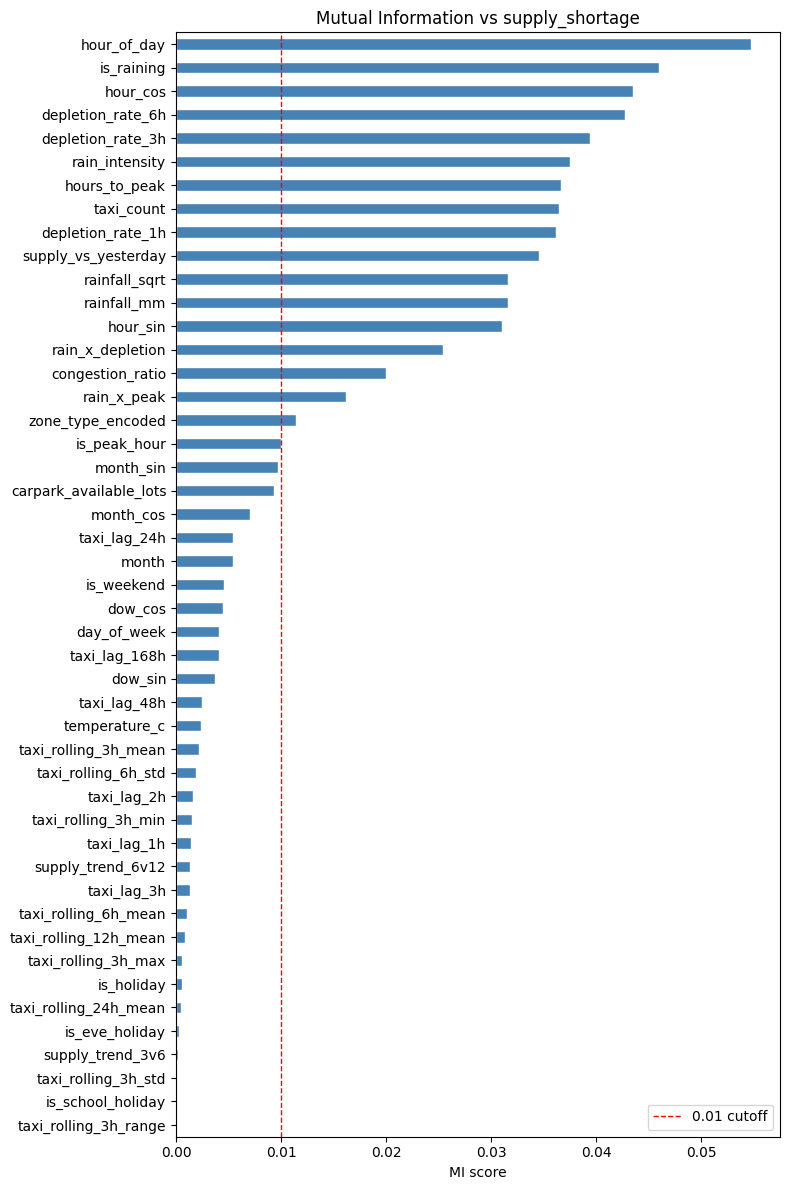


Selected: 23 features (MI ≥ 0.005)
Dropped:  ['is_weekend', 'dow_cos', 'day_of_week', 'taxi_lag_168h', 'dow_sin', 'taxi_lag_48h', 'temperature_c', 'taxi_rolling_3h_mean', 'taxi_rolling_6h_std', 'taxi_lag_2h', 'taxi_rolling_3h_min', 'taxi_lag_1h', 'supply_trend_6v12', 'taxi_lag_3h', 'taxi_rolling_6h_mean', 'taxi_rolling_12h_mean', 'taxi_rolling_3h_max', 'is_holiday', 'taxi_rolling_24h_mean', 'is_eve_holiday', 'supply_trend_3v6', 'taxi_rolling_3h_std', 'is_school_holiday', 'taxi_rolling_3h_range']


In [13]:
fig, ax = plt.subplots(figsize=(8, 12))
mi_df.sort_values().plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Mutual Information vs supply_shortage")
ax.set_xlabel("MI score")
ax.axvline(0.01, color="red", linestyle="--", linewidth=1, label="0.01 cutoff")
ax.legend()
plt.tight_layout()
plt.show()

# Drop features below MI threshold
MI_THRESHOLD = 0.005
selected = mi_df[mi_df >= MI_THRESHOLD].index.tolist()
dropped   = mi_df[mi_df < MI_THRESHOLD].index.tolist()
print(f"\nSelected: {len(selected)} features (MI ≥ {MI_THRESHOLD})")
print(f"Dropped:  {dropped}")

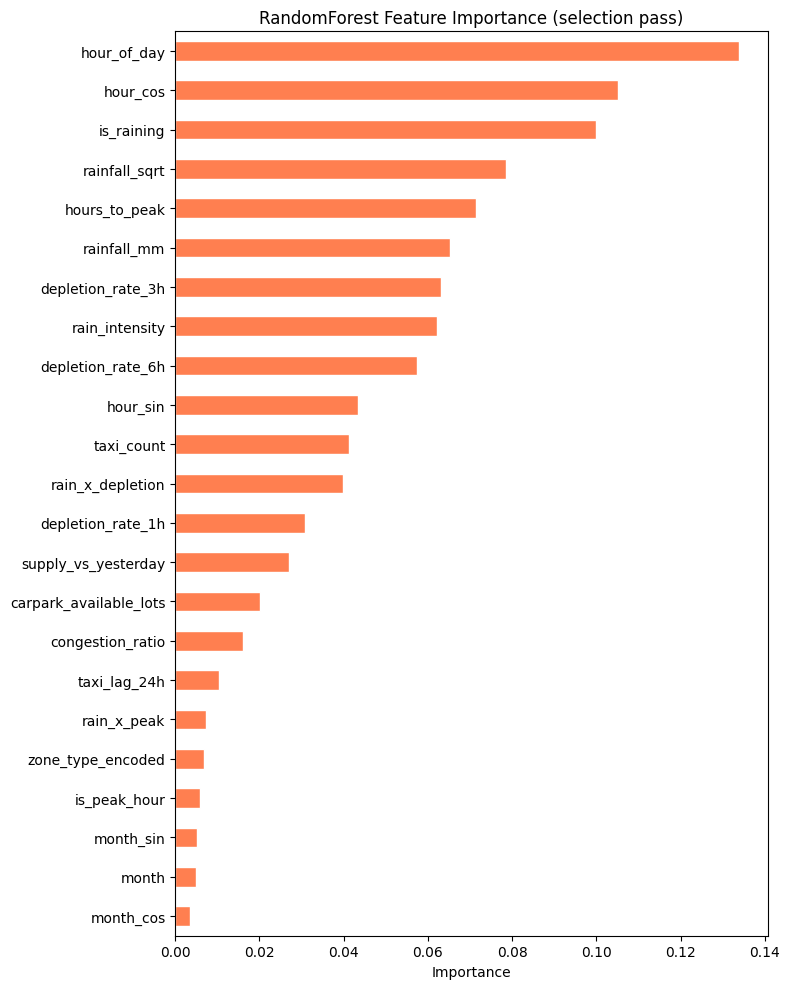

Top 15 by RF importance:
hour_of_day              0.1340
hour_cos                 0.1052
is_raining               0.1000
rainfall_sqrt            0.0785
hours_to_peak            0.0714
rainfall_mm              0.0652
depletion_rate_3h        0.0631
rain_intensity           0.0622
depletion_rate_6h        0.0575
hour_sin                 0.0434
taxi_count               0.0414
rain_x_depletion         0.0399
depletion_rate_1h        0.0309
supply_vs_yesterday      0.0270
carpark_available_lots   0.0202


In [14]:
# Quick RandomForest importance (50 trees — fast, more stable than single DT)
rf_sel = RandomForestClassifier(n_estimators=50, max_depth=8, class_weight="balanced",
                                 n_jobs=-1, random_state=42)
rf_sel.fit(X_sel[selected], y_sel)

imp_df = pd.Series(rf_sel.feature_importances_, index=selected).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
imp_df.sort_values().plot.barh(ax=ax, color="coral", edgecolor="white")
ax.set_title("RandomForest Feature Importance (selection pass)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 15 by RF importance:")
print(imp_df.head(15).to_string())

In [15]:
# Final feature set: features ranked in top 75% by RF importance
importance_threshold = imp_df.quantile(0.25)
FINAL_FEATURES = imp_df[imp_df >= importance_threshold].index.tolist()

print(f"Final feature set: {len(FINAL_FEATURES)} features")
print(FINAL_FEATURES)

Final feature set: 17 features
['hour_of_day', 'hour_cos', 'is_raining', 'rainfall_sqrt', 'hours_to_peak', 'rainfall_mm', 'depletion_rate_3h', 'rain_intensity', 'depletion_rate_6h', 'hour_sin', 'taxi_count', 'rain_x_depletion', 'depletion_rate_1h', 'supply_vs_yesterday', 'carpark_available_lots', 'congestion_ratio', 'taxi_lag_24h']


# =========================================================
# 6. TRAIN / TEST SPLIT
# =========================================================
Temporal split — no shuffle. Ensures model never trains on future data.

In [16]:
# Keep raw columns needed for zone normalization in step 7
KEEP_FOR_NORM = ["zone_id", "hour_of_day", "is_weekend", "taxi_count"]
# Deduplicate — FINAL_FEATURES may already contain these cols
split_cols = list(dict.fromkeys(
    FINAL_FEATURES + ["supply_shortage", "zone_name", "region"] + KEEP_FOR_NORM
))

split_df = df[[c for c in split_cols if c in df.columns]].copy()
for col in split_df.select_dtypes(include="bool").columns:
    split_df[col] = split_df[col].astype(int)

X = split_df.drop(columns=["supply_shortage"])
y = split_df["supply_shortage"]

# Temporal split — keep time ordering, no shuffle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

print(f"Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows")
print(f"Train shortage rate: {y_train.mean():.2%}")
print(f"Test shortage rate:  {y_test.mean():.2%}")

Train: 95,040 rows  |  Test: 23,760 rows
Train shortage rate: 12.70%
Test shortage rate:  12.56%


# =========================================================
# 7. HANDLE NULLS, ZONE NORMALISE & ENCODE
# =========================================================

In [17]:
# ── Zone normalization (fit on TRAIN only — avoids leakage) ──────────────────
zone_baseline = (
    X_train.groupby(["zone_id", "hour_of_day", "is_weekend"])["taxi_count"]
    .mean()
    .reset_index(name="zone_hour_baseline")
)

for part in [X_train, X_test]:
    part.reset_index(drop=True, inplace=True)
    merged = part.merge(zone_baseline, on=["zone_id","hour_of_day","is_weekend"], how="left")
    # Fill unmatched test-set zones with global mean
    global_mean = X_train["taxi_count"].mean()
    merged["zone_hour_baseline"] = merged["zone_hour_baseline"].fillna(global_mean)
    part["supply_vs_zone_baseline"] = (
        merged["taxi_count"] / (merged["zone_hour_baseline"] + 1)
    ).clip(0, 5).values

# Add to final feature list if not already there
if "supply_vs_zone_baseline" not in FINAL_FEATURES:
    FINAL_FEATURES.append("supply_vs_zone_baseline")

print(f"supply_vs_zone_baseline added — train sample: {X_train['supply_vs_zone_baseline'].describe().round(3)}")

supply_vs_zone_baseline added — train sample: count   95040.0000
mean        0.9510
std         0.2500
min         0.2600
25%         0.7480
50%         0.9520
75%         1.1420
max         1.8560
Name: supply_vs_zone_baseline, dtype: float64


In [18]:
# ── Drop raw helper columns ────────────────────────────────────────────────
drop_cols = ["zone_id", "zone_name", "region"]
drop_cols += [c for c in drop_cols if c in X_train.columns]

X_train = X_train[[c for c in FINAL_FEATURES + ["zone_name","region"] if c in X_train.columns]].copy()
X_test  = X_test [[c for c in FINAL_FEATURES + ["zone_name","region"] if c in X_test.columns ]].copy()

# ── Impute nulls ──────────────────────────────────────────────────────────────
for col in X_train.select_dtypes(include=[float, int]).columns:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col]  = X_test[col].fillna(median)

print(f"Nulls remaining: {X_train.isnull().sum().sum()}")

# ── One-hot encode ──────────────────────────────────────────────────────────
ohe_cols = [c for c in ["zone_name", "region"] if c in X_train.columns]
if ohe_cols:
    X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=True)
    X_test  = pd.get_dummies(X_test,  columns=ohe_cols, drop_first=True)
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(f"Features after OHE: {X_train.shape[1]}")

Nulls remaining: 0
Features after OHE: 65


In [19]:
# ── Scale numerical features ──────────────────────────────────────────────
# Fit on TRAIN only — no leakage into test set
scale_cols = [c for c in [
    "taxi_count", "rainfall_mm", "rainfall_sqrt", "temperature_c",
    "taxi_lag_1h", "taxi_lag_2h", "taxi_lag_3h", "taxi_lag_24h", "taxi_lag_48h", "taxi_lag_168h",
    "taxi_rolling_3h_mean", "taxi_rolling_6h_mean", "taxi_rolling_12h_mean", "taxi_rolling_24h_mean",
    "taxi_rolling_3h_std",  "taxi_rolling_6h_std",
    "taxi_rolling_3h_max",  "taxi_rolling_3h_min",  "taxi_rolling_3h_range",
    "depletion_rate_1h", "depletion_rate_3h", "depletion_rate_6h",
    "supply_vs_yesterday", "supply_trend_3v6", "supply_trend_6v12",
    "supply_vs_zone_baseline", "rain_x_depletion",
    "carpark_available_lots", "congestion_ratio", "hours_to_peak",
] if c in X_train.columns]

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test [scale_cols] = scaler.transform    (X_test [scale_cols])

print(f"Scaled {len(scale_cols)} numerical columns")
print(f"Final shape — Train: {X_train.shape}  |  Test: {X_test.shape}")

Scaled 13 numerical columns
Final shape — Train: (95040, 65)  |  Test: (23760, 65)


# =========================================================
# 8. BUILD DECISION TREE
# =========================================================

In [20]:
dt = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)
print("Model trained.")

Model trained.


# =========================================================
# 9. EVALUATE
# =========================================================

In [21]:
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No shortage", "Shortage"]))

print()
print("=== EXP 1 vs EXP 2 COMPARISON ===")
print(f"{'Metric':<12}  {'Exp 1':>8}  {'Exp 2':>8}  {'Delta':>8}")
print("-" * 42)

from sklearn.metrics import f1_score, precision_score, recall_score
exp2 = {
    "auc":       auc,
    "f1":        f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall":    recall_score(y_test, y_pred),
}
for m in ["auc", "f1", "precision", "recall"]:
    delta = exp2[m] - EXP1[m]
    sign  = "+" if delta >= 0 else ""
    print(f"{m:<12}  {EXP1[m]:>8.4f}  {exp2[m]:>8.4f}  {sign}{delta:>7.4f}")

ROC-AUC: 0.7669

              precision    recall  f1-score   support

 No shortage       0.91      0.84      0.88     20775
    Shortage       0.29      0.46      0.36      2985

    accuracy                           0.79     23760
   macro avg       0.60      0.65      0.62     23760
weighted avg       0.84      0.79      0.81     23760


=== EXP 1 vs EXP 2 COMPARISON ===
Metric           Exp 1     Exp 2     Delta
------------------------------------------
auc             0.8274    0.7669  -0.0605
f1              0.4128    0.3551  -0.0577
precision       0.4880    0.2909  -0.1971
recall          0.3576    0.4556  + 0.0980


# =========================================================
# 10. STRATIFIED 5-FOLD CV
# =========================================================

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

cv_scores = cross_val_score(dt, X_full, y_full, cv=skf, scoring="roc_auc")
print(f"Stratified 5-fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold scores: {[round(float(s), 4) for s in cv_scores]}")

Stratified 5-fold CV ROC-AUC: 0.8493 ± 0.0029
Per-fold scores: [0.8546, 0.847, 0.8492, 0.8492, 0.8465]


# =========================================================
# 11. SHAP EXPLANATION
# =========================================================

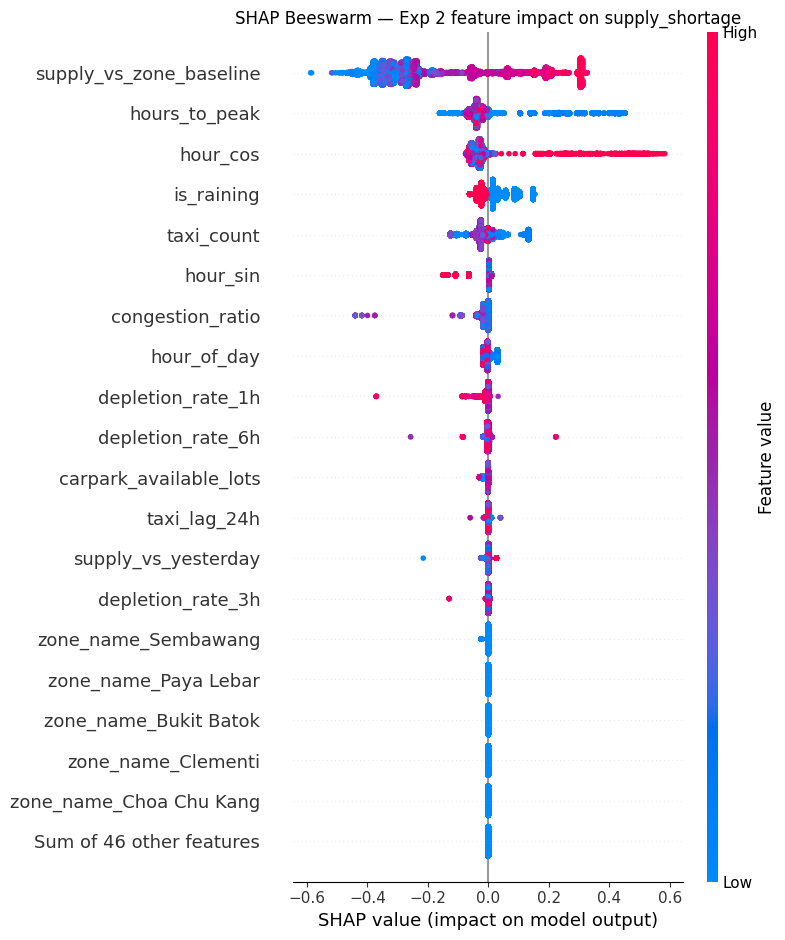

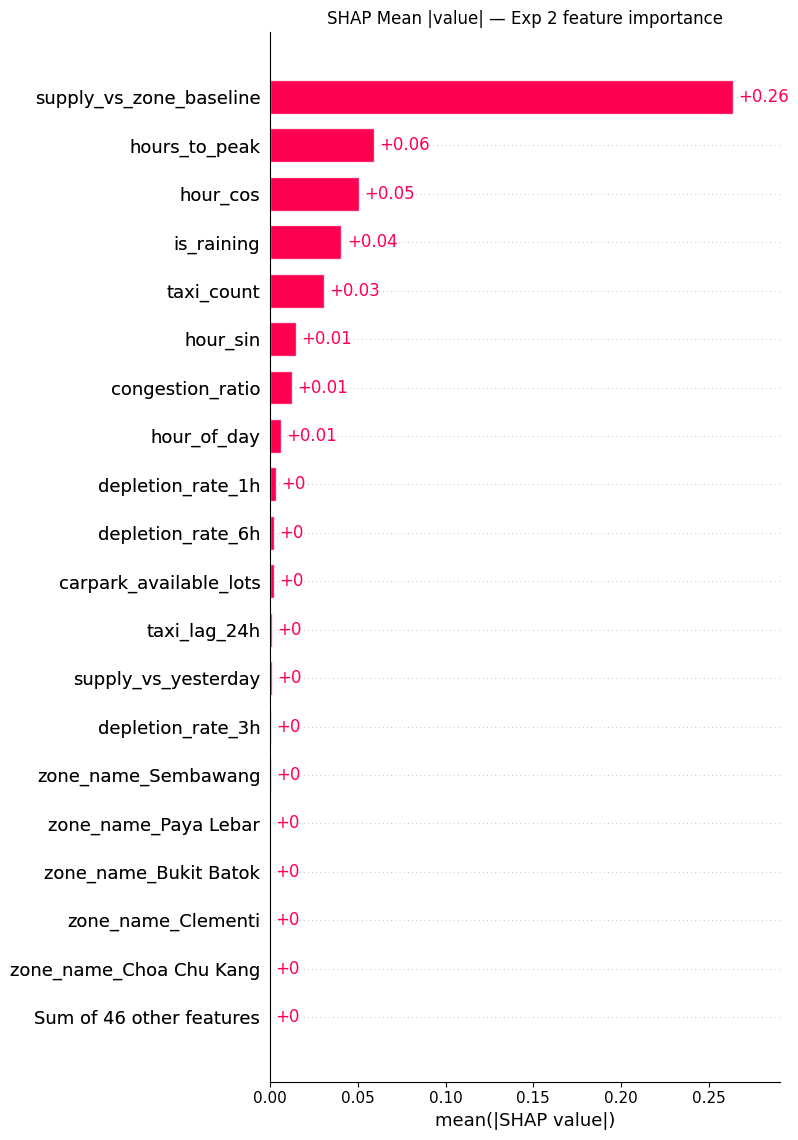

In [23]:
explainer  = shap.TreeExplainer(dt)
shap_values = explainer(X_test)
sv = shap_values[..., 1]

shap.plots.beeswarm(sv, max_display=20, show=False)
plt.title("SHAP Beeswarm — Exp 2 feature impact on supply_shortage")
plt.tight_layout()
plt.show()

shap.plots.bar(sv, max_display=20, show=False)
plt.title("SHAP Mean |value| — Exp 2 feature importance")
plt.tight_layout()
plt.show()